# 1. Introduction

In today’s financial markets, investors are often overwhelmed by a large number of financial metrics when comparing companies. This challenge is particularly significant for **beginner investors**, who may lack the experience to interpret complex financial data.

## Research Question

This project aims to address a simple but important question:

**How can beginner investors use a small set of financial ratios to compare the investment attractiveness of companies?**

## Companies Selected

This analysis focuses on three major global fast-food corporations:

- **McDonald's**
- **Yum! Brands**(KFC, Pizza Hut, Taco Bell...)
- **Restaurant Brands International**(Burger King, Tim Hortons, Popeyes...)

These firms operate in the same industry but differ in business models and growth strategies, making them suitable for comparison.

## Method Overview

Using data from **Compustat (via WRDS)**, this project constructs five key financial indicators:

- **ROE (Return on Equity)**
- **ROA (Return on Assets)**
- **Revenue Growth**
- **Leverage**
- **Profit Margin**

These indicators are combined into a **simple scoring system**.

## Objective

The goal is to provide a **clear and intuitive framework** that helps beginner investors make informed comparisons across companies.

This project emphasizes **clarity and interpretability over complexity**.

# 2. Data
This project uses financial data from Compustat, accessed via WRDS.

The sample includes three global fast-food companies: **McDonald's, Yum! Brands, Restaurant Brands International**.

The analysis focuses on annual data from **2019 to 2024**.

Key variables include: **Net income (ni), Total assets (at), Shareholders’ equity (ceq), Revenue (sale), Long-term debt (dltt)**.

These variables are used to construct financial ratios such as **ROE, ROA, revenue growth, leverage, and profit margin**.

## 2.1. Data source

In [2]:
import wrds
username = 'chuyuechen'
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


In [3]:
MCD = '007154'
YUM = '065417'
RBI = '164471'

data = db.raw_sql(f"""
SELECT gvkey, datadate, sale, ni, at, ceq, dltt
FROM comp.funda
WHERE gvkey IN ('{MCD}', '{YUM}', '{RBI}')
  AND indfmt = 'INDL'
  AND datafmt = 'STD'
  AND popsrc = 'D'
  AND consol = 'C'
  AND datadate BETWEEN '2019-01-01' AND '2024-12-31'
ORDER BY gvkey, datadate
""")

In [4]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
data

,gvkey,datadate,sale,ni,at,ceq,dltt
0,007154,2019-12-31,21076.5,6025.4,47510.8,-8210.3,46875.9
1,007154,2020-12-31,19207.8,4730.5,52626.8,-7824.9,48518.1
2,007154,2021-12-31,23222.9,7545.2,53854.3,-4601.0,48643.6
3,007154,2022-12-31,23182.6,6177.4,50435.6,-6003.4,48037.9
4,007154,2023-12-31,25493.7,8468.8,56146.8,-4706.7,50210.6
5,007154,2024-12-31,25920.0,8223.0,55182.0,-3797.0,51312.0
6,065417,2019-12-31,5597.0,1294.0,5231.0,-8016.0,10771.0
7,065417,2020-12-31,5652.0,904.0,5852.0,-7891.0,11095.0
8,065417,2021-12-31,6584.0,1575.0,5966.0,-8373.0,11971.0
9,065417,2022-12-31,6842.0,1325.0,5846.0,-8876.0,12184.0


## 2.2. Data Cleaning

In [5]:
##### import pandas as pd
import numpy as np

analysis_df = data.copy()

analysis_df['datadate'] = pd.to_datetime(analysis_df['datadate'])
analysis_df['year'] = analysis_df['datadate'].dt.year

company_map = {
    '007154': "McDonald's",
    '065417': "Yum Brands",
    '164471': "Restaurant Brands International"}

analysis_df['gvkey'] = analysis_df['gvkey'].astype(str).str.zfill(6)
analysis_df['company'] = analysis_df['gvkey'].map(company_map)

analysis_df = analysis_df.sort_values(['company', 'year']).reset_index(drop=True)

analysis_df['roa'] = analysis_df['ni'] / analysis_df['at']
analysis_df['roe'] = analysis_df['ni'] / analysis_df['ceq']
analysis_df['profit_margin'] = analysis_df['ni'] / analysis_df['sale']
analysis_df['leverage'] = analysis_df['dltt'] / analysis_df['at']

analysis_df['revenue_growth'] = analysis_df.groupby('company')['sale'].pct_change()

analysis_df

,gvkey,datadate,sale,ni,at,ceq,dltt,year,company,roa,roe,profit_margin,leverage,revenue_growth
0,007154,2019-12-31,21076.5,6025.4,47510.8,-8210.3,46875.9,2019,McDonald's,0.126822,-0.733883,0.285882,0.986637,<NA>
1,007154,2020-12-31,19207.8,4730.5,52626.8,-7824.9,48518.1,2020,McDonald's,0.089888,-0.604544,0.24628,0.921928,-0.088663
2,007154,2021-12-31,23222.9,7545.2,53854.3,-4601.0,48643.6,2021,McDonald's,0.140104,-1.639904,0.324903,0.903244,0.209035
3,007154,2022-12-31,23182.6,6177.4,50435.6,-6003.4,48037.9,2022,McDonald's,0.122481,-1.028984,0.266467,0.95246,-0.001735
4,007154,2023-12-31,25493.7,8468.8,56146.8,-4706.7,50210.6,2023,McDonald's,0.150833,-1.799307,0.332192,0.894274,0.099691
5,007154,2024-12-31,25920.0,8223.0,55182.0,-3797.0,51312.0,2024,McDonald's,0.149016,-2.165657,0.317245,0.929868,0.016722
6,164471,2019-12-31,5603.0,643.0,22360.0,2490.0,13136.0,2019,Restaurant Brands International,0.028757,0.258233,0.11476,0.587478,<NA>
7,164471,2020-12-31,4968.0,486.0,22777.0,2167.0,13794.0,2020,Restaurant Brands International,0.021337,0.224273,0.097826,0.605611,-0.113332
8,164471,2021-12-31,5739.0,838.0,23246.0,2237.0,14319.0,2021,Restaurant Brands International,0.036049,0.374609,0.146018,0.615977,0.155193
9,164471,2022-12-31,6505.0,1008.0,22746.0,2499.0,14177.0,2022,Restaurant Brands International,0.044315,0.403361,0.154958,0.623274,0.133473


## 2.3. Data Analysis

## Step 1. Profitability: ROA and Profit Margin.

This section uses ROA and Profit Margin to provide a simple comparison of firms' profitability for beginner investors.
$$
ROA = \frac{Net\ Income}{Total\ Assets}
$$
$$
Profit Margin = \frac{NI}{SALE}
$$

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

name_map = {
    '007154': 'MCD',
    '065417': 'YUM',
    '164471': 'RBI'
}

data['datadate'] = pd.to_datetime(data['datadate'])

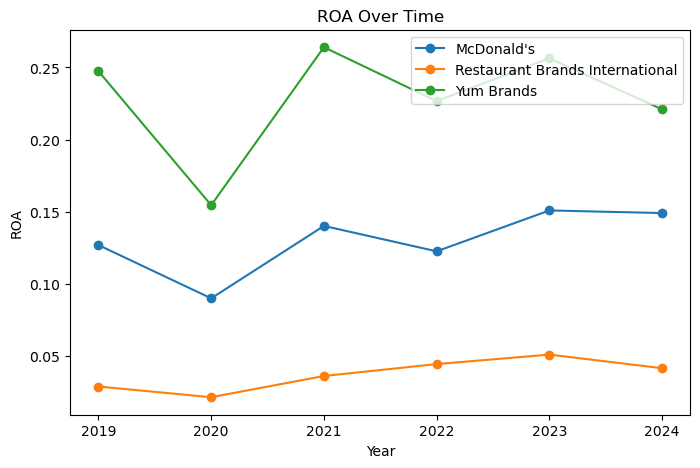

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for company in analysis_df['company'].unique():
    subset = analysis_df[analysis_df['company'] == company]
    plt.plot(subset['year'], subset['roa'], marker='o', label=company)

plt.xlabel('Year')
plt.ylabel('ROA')
plt.title('ROA Over Time')
plt.legend()
plt.show()

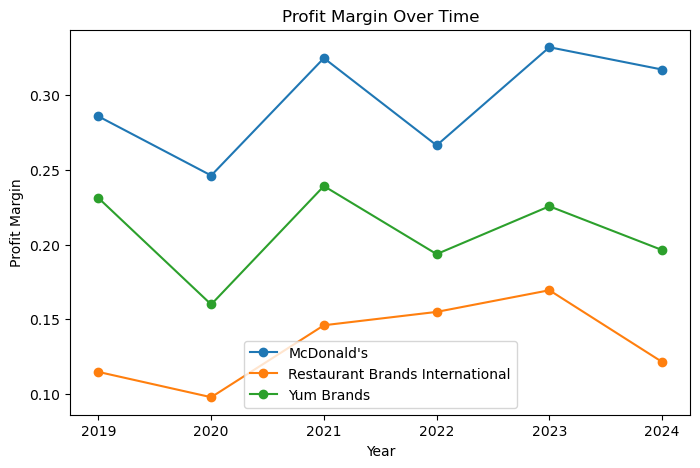

In [8]:
plt.figure(figsize=(8,5))

for company in analysis_df['company'].unique():
    subset = analysis_df[analysis_df['company'] == company]
    plt.plot(subset['year'], subset['profit_margin'], marker='o', label=company)

plt.xlabel('Year')
plt.ylabel('Profit Margin')
plt.title('Profit Margin Over Time')
plt.legend()
plt.show()

- **Structural Differences in Performance**  
  -**Yum Brands** consistently operates at a higher level across both ROA and Profit Margin, suggesting a structurally stronger and more mature business model.

  -**Restaurant Brands International** remains at the lower end throughout the period, indicating a persistent weakness in its profitability base rather than temporary fluctuations.

  -**McDonald’s** stays in the middle-to-high range, reflecting solid but not extreme overall performance.

- **Profitability vs Efficiency**  
  Comparing the two metrics reveals a clear distinction between profitability and efficiency.

  -**McDonald’s** achieves relatively high profit margins but lower ROA, implying that its asset utilization is less efficient. 
  -**Yum Brands** maintains leading ROA despite not always having the highest margins, indicating a stronger ability to convert assets into returns.

- **Resilience and Mean Reversion**  
  **Yum Brands** shows a sharp decline in 2020 followed by a strong recovery in 2021, suggesting high resilience and a clear mean reversion pattern. This indicates that its performance is less affected by short-term shocks over the longer term.

- **Common Trends and External Factors**  
  All three firms experience a decline around 2020, pointing to a shared external shock rather than firm-specific issues. However, the subsequent recovery differs: **McDonald’s** and **Yum Brands** rebound more strongly, while **Restaurant Brands International** remains at a lower level, suggesting weaker internal resilience despite facing similar external conditions.

## Step 2. ROE

Return on Equity (ROE) provides a quick measure of how efficiently a company generates returns on shareholders’ capital. To ensure a more accurate interpretation, we complement ROE with Net Income to distinguish between true profitability and the effects of financial structure.
$$
ROE = \frac{Net\ Income}{Equity}
$$

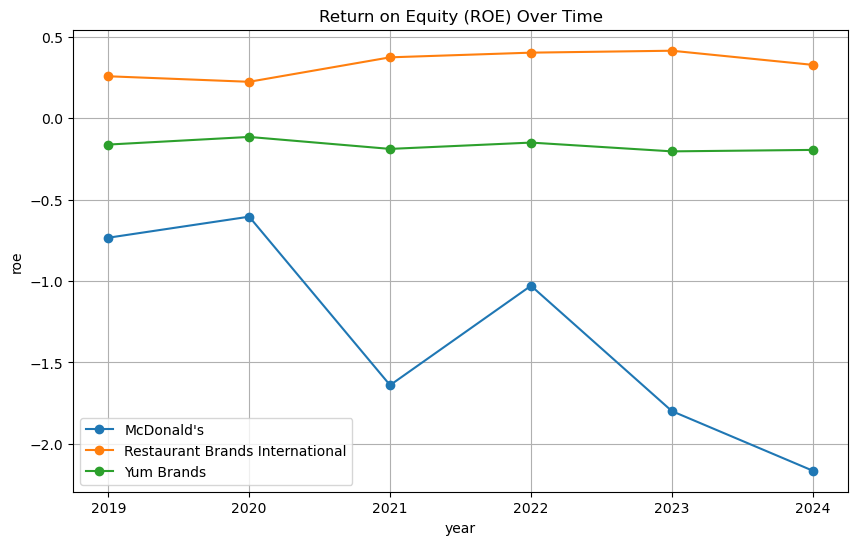

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for company in analysis_df['company'].unique():
    subset = analysis_df[analysis_df['company'] == company]
    plt.plot(subset['year'], subset['roe'], marker='o', label=company)
    
plt.title('Return on Equity (ROE) Over Time')
plt.xlabel('year')
plt.ylabel('roe')
plt.legend()
plt.grid(True)

plt.show()

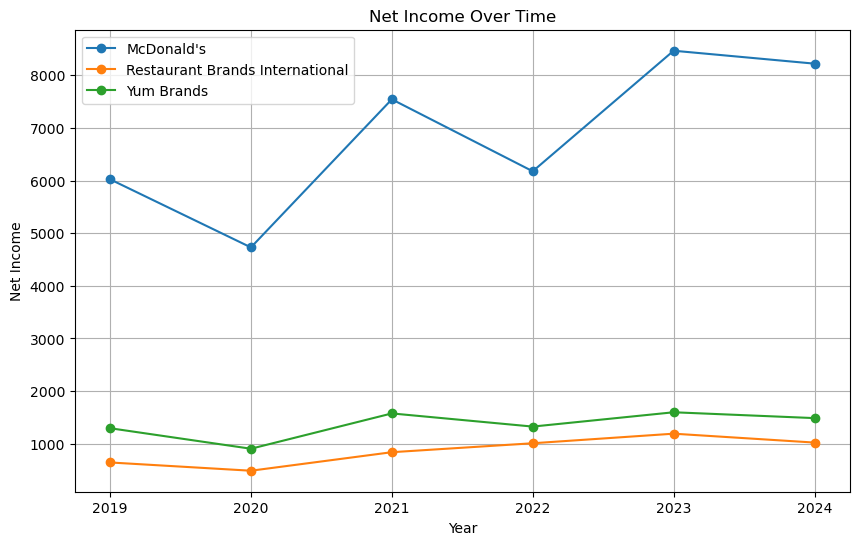

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for company in analysis_df['company'].unique():
    subset = analysis_df[analysis_df['company'] == company]
    plt.plot(subset['year'], subset['ni'], marker='o', label=company)

plt.title('Net Income Over Time')
plt.xlabel('Year')
plt.ylabel('Net Income')
plt.legend()
plt.grid(True)
plt.show()

- **Why Are Some ROE Values Negative?**

  The negative ROE observed for McDonald's and Yum Brands is **not driven by poor profitability**. Both companies report **positive Net Income** throughout the period, meaning they are consistently profitable. However, their **equity (CEQ) is negative**, likely due to high leverage and significant share repurchase activities. This demonstrates that ROE can be misleading when capital structure is unusual.

- **Comparison Across Firms**

  Unlike McDonald's and Yum Brands, RBI maintains a positive equity base, resulting in more reliable and interpretable ROE values.
  This suggests that:

  -RBI’s ROE more accurately reflects its **true operating performance**.

  -The negative ROE of the other firms is primarily a **structural artifact**, rather than a sign of weak performance.

- **Implications for Beginner Investors**

  ROE is a powerful starting point because it summarizes how efficiently a company generates returns for shareholders. However, ROE alone   can be misleading, especially when firms have **unconventional capital structures**.

  To make better investment comparisons, beginner investors should:

  -Avoid relying on a **single ratio in isolation**.

  
  -Combine ROE with complementary indicators such as: **Net Income** (to assess profitability), **Leverage** (to understand financial       structure).

  By using a small set of financial ratios together, investors can form a more reliable and nuanced assessment of a company’s investment    attractiveness.

- **Investment perspective**

  All three companies are consistently profitable, but differ in financial structure and risk. **McDonald's and Yum Brands** generate       strong earnings, yet their negative equity suggests higher reliance on leverage, which can distort ROE and increase financial risk. In    contrast, **Restaurant Brands International** maintains a positive equity base and more stable, interpretable ROE, making its             performance easier to evaluate. For beginner investors, this implies that while high returns may be attractive, it is equally important   to consider how those returns are generated and the underlying financial risk.

## Step 3. Revenue Growth

Revenue growth measures how quickly a company increases its sales over time and reflects its expansion potential. It is calculated as:

$$
Revenue\ Growth = \frac{Revenue_t - Revenue_{t-1}}{Revenue_{t-1}}
$$

This metric helps investors assess whether a firm can sustain and grow its operations beyond current profitability.

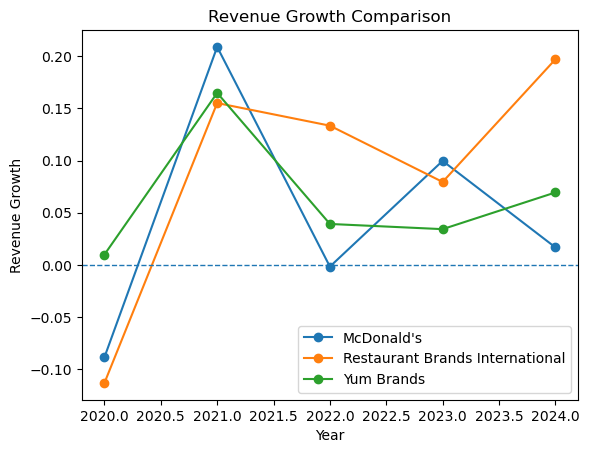

In [11]:
import matplotlib.pyplot as plt

for company, group in analysis_df.groupby('company'):
    plt.plot(group['year'], group['revenue_growth'], marker='o', label=company)

plt.axhline(0, linestyle='--', linewidth=1)
plt.legend()
plt.title("Revenue Growth Comparison")
plt.xlabel("Year")
plt.ylabel("Revenue Growth")
plt.show()

### RBI: Growth Driven by Expansion, Not Efficiency

From the revenue growth chart, RBI maintains positive growth from 2021 to 2024, reaching close to 20% in 2024. On the surface, it appears to have the strongest growth among the three companies.

However, when we **look at this together with ROA, profit margin, and net income**, a different picture emerges:

- Its ROA is consistently the lowest, roughly around 2%–5%
- Its profit margin is also the lowest, approximately 10%–17%
- Although net income is increasing, its absolute level is significantly lower than McDonald’s

What does this mean?

It suggests that RBI is indeed expanding its revenue, but it is less effective at converting that revenue into profit and asset returns. In other words, it has growth, but the “quality” of that growth is relatively low.

From an investment perspective, this implies:

> RBI’s growth is more likely driven by scale expansion rather than high-quality, efficient growth. Therefore, it is not sufficient to conclude that RBI is the most attractive investment simply because it has the highest growth, as this growth is not supported by strong profitability.

### McDonald’s: Volatile Growth with Strong Profitability

From the revenue growth chart, McDonald’s shows the most volatile pattern. If we only look at revenue growth, it may seem unstable. However, when we compare this with other metrics:

- Net income remains the highest across all years
- Profit margin is consistently the highest (around 25%–33%)
- ROA is also clearly stronger than RBI

This suggests that McDonald’s issue is not weak profitability, but rather fluctuations in revenue growth. And revenue growth volatility in this case does not necessarily imply weaker investment attractiveness.

From an investment perspective, this implies:

> McDonald’s does not rely on stable growth to generate strong financial performance. It is able to maintain high profitability even when growth is unstable, which reflects a mature and highly efficient business model. McDonald’s offers a profitability-driven investment profile, where strong and consistent earnings can offset the impact of unstable revenue growth.

### Yum Brands: Balanced and Sustainable Growth

From the revenue growth chart, Yum Brands maintains moderate growth, generally between 3% and 7%, without extreme fluctuations.

When combined with other metrics:

- It has the highest ROA
- Profit margin is at a solid mid-to-high level
- Net income shows stable and consistent growth

This indicates that Yum Brands is not focused on aggressive expansion, but instead achieves a balance between growth, efficiency, and profitability.

From an investment perspective, this implies:

> Yum Brands may be more suitable for beginner investors seeking a balance between growth and profitability, supported by relatively stable performance. Its moderate but consistent growth, combined with strong efficiency, suggests a more sustainable and predictable investment profile.




## Step 4: Risk Analysis — Leverage

Leverage is used to evaluate a company's financial risk by showing how much debt it uses relative to its equity. In general, a higher leverage ratio suggests greater financial risk, because the company may face stronger repayment pressure and higher sensitivity to changes in earnings or interest rates.

$$
Leverage = \frac{Long\text{-}Term\ Debt}{Equity}
$$

To compare the three companies, this step analysis both:
- the **level of leverage** across years, and
- the **stability of leverage** over time.

### 1. Use Group Bar Chat to show risk level and risk trend.

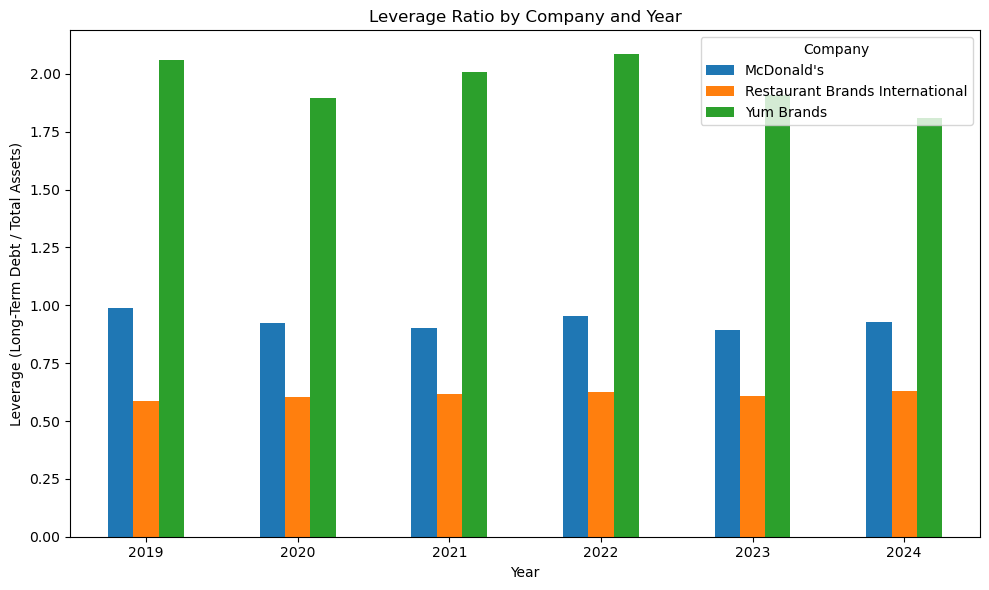

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

leverage_pivot = analysis_df.pivot(index="year", columns="company", values="leverage")

leverage_pivot.plot(kind="bar", figsize=(10, 6))

plt.title("Leverage Ratio by Company and Year")
plt.xlabel("Year")
plt.ylabel("Leverage (Long-Term Debt / Total Assets)")
plt.xticks(rotation=0)
plt.legend(title="Company")
plt.tight_layout()
plt.show()

A basic interpretation is that **higher leverage implies greater financial risk**, because a larger portion of the firm’s asset base is supported by debt. From this perspective, Yum Brands appears the riskiest, RBI the most conservative, and McDonald’s lies in between.

However, **leverage should not be assessed in isolation**. Debt becomes problematic only when a company lacks the profitability and efficiency needed to support it. Therefore, leverage must be interpreted together with the earlier results on revenue growth, profit margin, ROA, and net income.

### Yum Brands: Stable operations, but debt-dependent structure

Yum Brands appears relatively stable in revenue growth and shows moderate profitability. However, its consistently high leverage suggests that this stability is supported by a much more debt-heavy capital structure.

This matters because high leverage can enhance downside risk:

- interest obligations reduce financial flexibility;
- the company becomes more vulnerable during economic slowdowns;
- future expansion may rely more heavily on financing conditions.

> Therefore, while Yum Brands looks stable from a growth perspective, its balance sheet introduces an additional layer of financial risk that beginner investors should not ignore.


### McDonald’s: Moderate leverage supported by strong fundamentals

McDonald’s has more volatile revenue growth, but its leverage ratio remains relatively controlled and stable. More importantly, the company also shows the strongest profitability metrics in the group, including the highest profit margin, strong ROA, and the largest net income.

This combination changes the interpretation of leverage. Moderate debt is less concerning when the company has strong earnings power, because profits provide a buffer against financial obligations. In this sense, McDonald’s leverage appears **manageable rather than excessive**.

> For investors, this suggests that McDonald’s may be more resilient than its growth volatility initially implies. Its business model generates enough profit to support debt while still maintaining strong operating performance.


### RBI: Conservative financing, but weaker efficiency

RBI has the lowest leverage, which indicates a more conservative financing position and lower balance-sheet risk. This is a positive sign, especially for beginner investors who may prefer companies with less debt exposure.

However, **low leverage does not automatically make a company more attractive**. Earlier charts show that RBI has weaker profitability and efficiency compared with McDonald’s. This suggests that although its financing risk is lower, its operating quality is not as strong.

> In other words, RBI is less risky from a debt perspective, but it is also less impressive in turning growth into returns.

This shows that beginner investors should not interpret leverage mechanically.  
A high ratio is a warning sign, but its significance depends on whether the company has the earnings strength to support it.

**Overall, the most attractive company is not necessarily the one with the lowest leverage, but the one that balances debt, profitability, and growth most effectively.**

### 2. Use Box Plot to show risk volatility.
The median line shows the typical leverage level.

The height of the box indicates how stable the leverage is over time, shorter--stable, taller--risk and uncertainty.

The whiskers reflect extreme values.

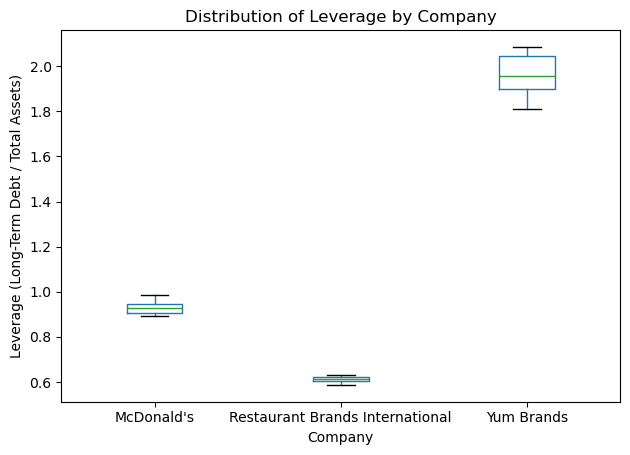

In [13]:
analysis_df.boxplot(
    column="leverage",
    by="company",
    grid=False
)

plt.title("Distribution of Leverage by Company")
plt.suptitle("")
plt.xlabel("Company")
plt.ylabel("Leverage (Long-Term Debt / Total Assets)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### What Does Leverage Volatility Indicate?

Leverage volatility reflects how a company’s capital structure (debt vs equity) changes over time. It provides important insights beyond the average level of debt.

There are three key dimensions to interpret leverage volatility:

- **Capital Structure Stability**  
  Low volatility suggests a stable and consistent financing policy, while high volatility indicates frequent changes in debt levels.

- **Financing Strategy**  
  Stable leverage implies long-term planning, whereas fluctuating leverage suggests that the firm actively adjusts its borrowing in response to expansion needs or financial conditions.

- **Financial Risk and Uncertainty**  
  Higher volatility increases uncertainty, especially when combined with high leverage. This can amplify financial risk because both the level and predictability of debt become concerns.



  This distribution shows a clear structural difference in financial risk across the three firms. Yum Brands not only has the highest leverage level, but also the widest distribution, indicating both heavy reliance on debt and greater variation in its capital structure over time. In contrast, Restaurant Brands International (RBI) exhibits both the lowest leverage and the narrowest distribution, suggesting a consistently conservative financing approach. McDonald’s lies between the two, with moderate leverage and relatively low variability.

### combined with other financial indicators

  Yum Brands appears relatively stable in revenue growth and maintains moderate profit margins, but its high and variable leverage introduces a hidden risk. The firm’s performance may look stable from an operational perspective, yet its dependence on debt implies that part of this stability is supported by financial leverage. This means that in less favourable conditions, such as rising interest rates or declining earnings, its risk could materialise more quickly.

  McDonald’s presents a contrasting case. Although its revenue growth is more volatile, it consistently achieves the highest profit margins and strong net income levels. When viewed alongside its moderate and stable leverage distribution, this suggests that its financial structure is well supported by strong earnings capacity. In other words, McDonald’s does not rely on increasing debt to sustain performance, making its overall risk profile more manageable despite fluctuations in growth.

  RBI, on the other hand, shows the lowest financial risk from a leverage perspective, as indicated by both low levels and minimal variation. However, its weaker profitability and lower returns imply that this conservative structure does not translate into superior performance. This highlights an important limitation for investors: low leverage reduces financial risk, but does not necessarily enhance investment attractiveness if the firm cannot generate strong returns.

  Overall, the leverage box plot helps investors distinguish between three fundamentally different profiles:
  
- A **high-leverage, variable structure (Yum Brands)**, where financial risk is elevated despite stable operations.
- A **moderate and stable leverage structure supported by strong profitability (McDonald’s)**, indicating a more balanced and resilient business model.
- A **low-risk but lower-return structure (RBI)**, where financial conservatism comes at the cost of weaker performance.

For beginner investors, this demonstrates that leverage should not be evaluated in isolation. Its true value lies in how it interacts with profitability and growth, helping to reveal whether a company’s performance is driven by operational strength or supported by financial risk.

# 3. Conclusion

All three companies' financial characteristics differ significantly when profitability, growth, and risk are considered together.

Yum Brands demonstrates strong overall performance in terms of profitability and efficiency, and its results are relatively consistent across time. However, its leverage shows noticeable volatility, indicating that its financial risk is not entirely stable. This suggests that while Yum Brands appears operationally strong, it may still carry underlying financial risk that beginner investors should be aware of.

McDonald’s presents a more balanced profile across the three dimensions. It maintains strong profitability and does not exhibit extreme behavior in either growth or leverage. Although some fluctuations exist, they are less pronounced compared to the other companies. This makes McDonald’s a relatively stable and predictable option when considering both return and risk together.

Restaurant Brands International stands out for its higher growth potential, but this comes with weaker profitability and greater overall risk. Its financial structure appears less stable, suggesting that its performance may be more sensitive to external factors. For beginner investors, this highlights the importance of not relying solely on growth indicators.

Overall, no single company dominates across all dimensions. Yum Brands is strong but carries leverage-related risk, McDonald’s offers the most balanced risk-return profile, and Restaurant Brands International represents a higher-risk, higher-growth profile.